# 04. 주식 quantile / long-short 백테스트

- `epsilon_dagger` (표준화 이상 수익률) 계산: `eps = r - r_hat`, `eps_dagger = eps / xi`
- 5 quantile 동일가중 포트폴리오 (1Q = eps_dagger 최저 = 저평가)
- long 1Q / short 5Q spread, 리밸런싱 매 20영업일
- reverse trade 제한 전/후 비교
- offset별 백테스트 → 동일가중 앙상블

논문 설정: `tau_star=20, quantiles=5, long=1Q, short=5Q, equal weight`

In [1]:
# 공통 설정 (00_environment_check.ipynb 와 동일)
from pathlib import Path
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SAMPLE_DIR = DATA_DIR / "sample"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
RESULT_DIR = REPORT_DIR / "results"
for p in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, FIG_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Cell 1: 설정 + 공통 함수 로드

In [2]:
# 01_data_and_returns.ipynb 에서 저장한 processed 데이터 로드
with open(PROCESSED_DIR / "stock_panel.pkl", "rb") as fh:
    panel = pickle.load(fh)

prices = panel["prices"]
returns_by_tau = panel["returns_by_tau"]
norm_by_tau = panel["norm_by_tau"]
sigma_by_tau = panel["sigma_by_tau"]
TAU_MAX = max(returns_by_tau.keys())
dates = prices.index
print("assets:", prices.shape[1], "| days:", prices.shape[0], "| tau: 1..%d" % TAU_MAX)

assets: 100 | days: 3000 | tau: 1..20


In [3]:
LOOKBACK = 1200  # 논문: 타임스케일당 학습 샘플 수 고정


def build_train_positions(t_pos: int, tau: int, lookback: int = LOOKBACK) -> list:
    # t_train_tau(t) = { t-(tau-1)-1, ..., t-(tau-1)-lookback }
    # 현재 시점 수익률과 기간이 겹치는 최근 tau-1개 시점을 제외해 정보 누수를 방지
    end = t_pos - (tau - 1)          # exclusive
    start = end - lookback
    if start < tau:
        raise ValueError(f"t_pos={t_pos}, tau={tau}: 학습 구간이 데이터 범위를 벗어남")
    return list(range(start, end))


def valid_assets(norm_by_tau: dict, t_pos: int, tau_star: int, lookback: int = LOOKBACK) -> list:
    # 학습 구간 + 현재 시점 모두에서 결측이 없는 자산만 사용 (날짜별 investable universe)
    ok = None
    for tau in range(1, tau_star + 1):
        pos = build_train_positions(t_pos, tau, lookback) + [t_pos]
        good = norm_by_tau[tau].iloc[pos].notna().all(axis=0)
        ok = good if ok is None else (ok & good)
    return list(ok.index[ok])


def extract_matrix(norm_returns: pd.DataFrame, positions: list, assets: list) -> np.ndarray:
    X = norm_returns.iloc[positions][assets].to_numpy(dtype=np.float32)
    if np.isnan(X).any():
        raise ValueError("학습 행렬에 NaN 존재 - universe 처리 필요")
    return X


def build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # STS: tau = tau_star 만 사용
    pos = build_train_positions(t_pos, tau_star, lookback)
    return extract_matrix(norm_by_tau[tau_star], pos, assets)


def build_mts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # MTS: tau = 1..tau_star 전부 사용 -> 샘플 수 = lookback * tau_star
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star + 1)
    ]
    return np.vstack(mats)


def build_ft_datasets(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # FT: tau = 1..tau_star-1 로 pre-train 후 tau_star 로 fine-tune
    X_ft = build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback)
    if tau_star == 1:
        return None, X_ft
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star)
    ]
    return np.vstack(mats), X_ft



class AutoEncoder(nn.Module):
    # Input(N) -> Dense(M, middle_activation) -> Dense(N, linear),  M = N * C
    def __init__(self, n_assets, compression_ratio=0.5, middle_activation="linear"):
        super().__init__()
        n_hidden = max(1, int(n_assets * compression_ratio))
        act = nn.Identity() if middle_activation == "linear" else nn.Tanh()
        self.encoder = nn.Sequential(nn.Linear(n_assets, n_hidden), act)
        self.decoder = nn.Linear(n_hidden, n_assets)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)



def train_autoencoder(X_train: np.ndarray, config: dict, model: nn.Module = None) -> nn.Module:
    device = config["device"]
    torch.manual_seed(config["seed"])
    if model is None:
        model = AutoEncoder(
            X_train.shape[1],
            config["compression_ratio"],
            config["middle_activation"],
        ).to(device)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
    loss_fn = nn.MSELoss()
    X = torch.tensor(X_train, dtype=torch.float32, device=device)
    n, bs = X.shape[0], config["batch_size"]
    gen = torch.Generator().manual_seed(config["seed"])
    for _ in range(config["epochs"]):
        perm = torch.randperm(n, generator=gen).to(device)
        for i in range(0, n, bs):
            xb = X[perm[i : i + bs]]
            opt.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward()
            opt.step()
    return model


def pretrain_and_finetune(X_pre, X_ft, config):
    if X_pre is None:
        return train_autoencoder(X_ft, config)
    model = train_autoencoder(X_pre, config)
    return train_autoencoder(X_ft, config, model=model)


def reconstruct(model: nn.Module, X: np.ndarray) -> np.ndarray:
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32, device=device))
    return out.cpu().numpy()


def compute_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [4]:
SMOKE = True

TAU_STAR = 20
N_QUANTILES = 5
LONG_Q, SHORT_Q = 1, 5

CONFIG = {
    "epochs": 30 if SMOKE else 50,
    "batch_size": 128,
    "lr": 1e-3,
    "compression_ratio": 0.5,
    "middle_activation": "linear",
    "seed": SEED,
    "device": DEVICE,
}

# 백테스트 구간: 데이터 마지막 부분 (03 테스트 구간과 겹치지 않음)
BACKTEST_DAYS = 420 if SMOKE else 1000
OFFSETS = [0, 5, 10, 15] if SMOKE else list(range(TAU_STAR))

end_pos = len(dates) - 1 - TAU_STAR          # t + tau_star 수익률이 필요
start_pos = end_pos - BACKTEST_DAYS
assert start_pos >= LOOKBACK + 2 * TAU_STAR
print(f"백테스트: {dates[start_pos].date()} ~ {dates[end_pos].date()}, offsets={OFFSETS}")

백테스트: 2019-10-25 ~ 2021-06-04, offsets=[0, 5, 10, 15]


## Cell 2: abnormal return 계산 함수

In [5]:
def compute_abnormal_return(realized: np.ndarray, reconstructed: np.ndarray) -> np.ndarray:
    # epsilon_i = r_i - r_hat_i
    return realized - reconstructed


def compute_asset_reconstruction_rmse(X_train, X_hat_train) -> np.ndarray:
    # xi_i = sqrt(mean_t((r_i(t') - r_hat_i(t'))^2))  (tau_star 학습 데이터 기준)
    return np.sqrt(np.mean((X_train - X_hat_train) ** 2, axis=0))


def standardize_abnormal_return(epsilon, xi) -> np.ndarray:
    # epsilon_dagger_i = epsilon_i / xi_i
    return epsilon / xi


def assign_quantiles(eps_dagger: pd.Series, n_quantiles: int) -> pd.Series:
    # 1 = epsilon_dagger 최저 (가장 저평가) ... n = 최고 (가장 고평가)
    ranks = eps_dagger.rank(method="first")
    return pd.qcut(ranks, n_quantiles, labels=False).astype(int) + 1


def apply_reverse_trade_restriction(long_cand, short_cand, prev_long, prev_short):
    # 직전 리밸런싱 long -> 이번 short 후보 제외 / 직전 short -> 이번 long 후보 제외
    long_final = [a for a in long_cand if a not in prev_short]
    short_final = [a for a in short_cand if a not in prev_long]
    return long_final, short_final

In [6]:
def compute_signal(t_pos, tau_star, norm_by_tau, config):
    # 기준 시점 t 에서 MTS 오토인코더 학습 후 epsilon_dagger 계산
    assets = valid_assets(norm_by_tau, t_pos, tau_star)
    X_mts = build_mts_dataset(t_pos, tau_star, norm_by_tau, assets)
    model = train_autoencoder(X_mts, config)

    # xi: tau_star 스케일 학습 데이터의 자산별 reconstruction RMSE
    X_ts = build_sts_dataset(t_pos, tau_star, norm_by_tau, assets)
    xi = compute_asset_reconstruction_rmse(X_ts, reconstruct(model, X_ts))

    x_now = norm_by_tau[tau_star].iloc[t_pos][assets].to_numpy(dtype=np.float32)
    x_hat = reconstruct(model, x_now[None, :])[0]
    eps = compute_abnormal_return(x_now, x_hat)
    eps_dagger = standardize_abnormal_return(eps, xi)
    return pd.Series(eps_dagger, index=assets)

## Cell 3~4: quantile 포트폴리오 / reverse trade 제한 / 백테스트 루프

In [7]:
import time

def run_offset_backtest(offset):
    # 한 offset 의 리밸런싱 날짜들: start_pos+offset 부터 tau_star 간격
    reb_positions = list(range(start_pos + offset, end_pos + 1, TAU_STAR))
    prev = {"plain": (set(), set()), "restricted": (set(), set())}
    rec_rows, eps_rows, memberships = [], {}, []

    for t_pos in reb_positions:
        eps_dagger = compute_signal(t_pos, TAU_STAR, norm_by_tau, CONFIG)
        q = assign_quantiles(eps_dagger, N_QUANTILES)

        # 이후 tau_star 일간 실현 수익률 (raw)
        fwd = returns_by_tau[TAU_STAR].iloc[t_pos + TAU_STAR]
        fwd = fwd.reindex(eps_dagger.index).astype(float)
        universe_ret = fwd.mean()

        row = {"offset": offset, "date": dates[t_pos].date().isoformat()}
        for k in range(1, N_QUANTILES + 1):
            members = q.index[q == k]
            row[f"q{k}_active"] = fwd[members].mean() - universe_ret

        long_cand = list(q.index[q == LONG_Q])
        short_cand = list(q.index[q == SHORT_Q])

        for mode in ["plain", "restricted"]:
            if mode == "restricted":
                pl, ps = prev[mode]
                longs, shorts = apply_reverse_trade_restriction(long_cand, short_cand, pl, ps)
            else:
                longs, shorts = long_cand, short_cand
            ls = fwd[longs].mean() - fwd[shorts].mean()
            pl, ps = prev[mode]
            n_prev = len(pl) + len(ps)
            n_kept = len(set(longs) & pl) + len(set(shorts) & ps)
            row[f"ls_{mode}"] = ls
            row[f"turnover_{mode}"] = 1.0 - n_kept / n_prev if n_prev else np.nan
            row[f"n_long_{mode}"], row[f"n_short_{mode}"] = len(longs), len(shorts)
            prev[mode] = (set(longs), set(shorts))

        rec_rows.append(row)
        eps_rows[dates[t_pos]] = eps_dagger
        memberships.append({"date": dates[t_pos], "long": set(long_cand), "short": set(short_cand)})

    eps_panel = pd.DataFrame(eps_rows).T          # index: date, columns: asset
    return pd.DataFrame(rec_rows), eps_panel, memberships


all_rec, eps_panels, memberships_by_offset = [], {}, {}
t0 = time.time()
for offset in OFFSETS:
    rec, eps_panel, members = run_offset_backtest(offset)
    all_rec.append(rec)
    eps_panels[offset] = eps_panel
    memberships_by_offset[offset] = members
    print(f"offset {offset}: 리밸런싱 {len(rec)}회 완료 ({time.time() - t0:.0f}s)", flush=True)

df_bt = pd.concat(all_rec, ignore_index=True)
df_bt["date"] = pd.to_datetime(df_bt["date"])
print("총 리밸런싱 횟수:", len(df_bt))

offset 0: 리밸런싱 22회 완료 (100s)


offset 5: 리밸런싱 21회 완료 (193s)


offset 10: 리밸런싱 21회 완료 (280s)


offset 15: 리밸런싱 21회 완료 (368s)


총 리밸런싱 횟수: 85


## Cell 5: 결과 저장

In [8]:
q_cols = [f"q{k}_active" for k in range(1, N_QUANTILES + 1)]
df_bt[["offset", "date"] + q_cols].to_csv(RESULT_DIR / "quantile_returns.csv", index=False)
ls_cols = ["ls_plain", "ls_restricted", "turnover_plain", "turnover_restricted",
           "n_long_restricted", "n_short_restricted"]
df_bt[["offset", "date"] + ls_cols].to_csv(RESULT_DIR / "long_short_returns.csv", index=False)

with open(PROCESSED_DIR / "backtest_signals.pkl", "wb") as fh:
    pickle.dump({
        "eps_panels": eps_panels,
        "memberships_by_offset": memberships_by_offset,
        "tau_star": TAU_STAR,
        "offsets": OFFSETS,
    }, fh)
print("saved: quantile_returns.csv / long_short_returns.csv / backtest_signals.pkl")

saved: quantile_returns.csv / long_short_returns.csv / backtest_signals.pkl


## Cell 6: offset 앙상블 (동일가중 평균)

In [9]:
bt_dates = dates[start_pos : end_pos + 1]

def ensemble_cumulative(col):
    # offset별 리밸런싱 수익률의 누적합을 일별로 늘린 뒤 offset 평균
    curves = {}
    for offset, g in df_bt.groupby("offset"):
        s = g.set_index("date")[col].cumsum()
        curves[offset] = s
    df = pd.DataFrame(curves).sort_index()
    df = df.reindex(bt_dates).ffill().fillna(0.0)
    return df.mean(axis=1)

ens_quantile = {k: ensemble_cumulative(f"q{k}_active") for k in range(1, N_QUANTILES + 1)}
ens_ls_plain = ensemble_cumulative("ls_plain")
ens_ls_restricted = ensemble_cumulative("ls_restricted")

## Cell 7: quantile별 active return

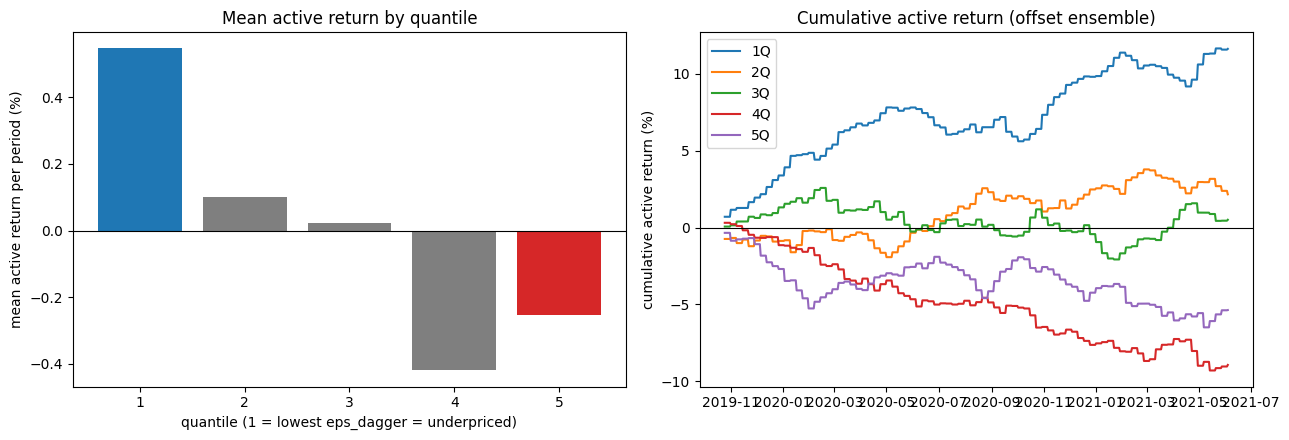

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mean_active = df_bt[q_cols].mean() * 100
axes[0].bar(range(1, N_QUANTILES + 1), mean_active.values,
            color=["tab:blue"] * 1 + ["tab:gray"] * 3 + ["tab:red"] * 1)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("quantile (1 = lowest eps_dagger = underpriced)")
axes[0].set_ylabel("mean active return per period (%)")
axes[0].set_title("Mean active return by quantile")

for k in range(1, N_QUANTILES + 1):
    axes[1].plot(ens_quantile[k].index, ens_quantile[k].values * 100, label=f"{k}Q")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("cumulative active return (%)")
axes[1].set_title("Cumulative active return (offset ensemble)")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "quantile_active_return.png", dpi=120)
plt.show()

## Cell 8: long-short spread 누적 그래프

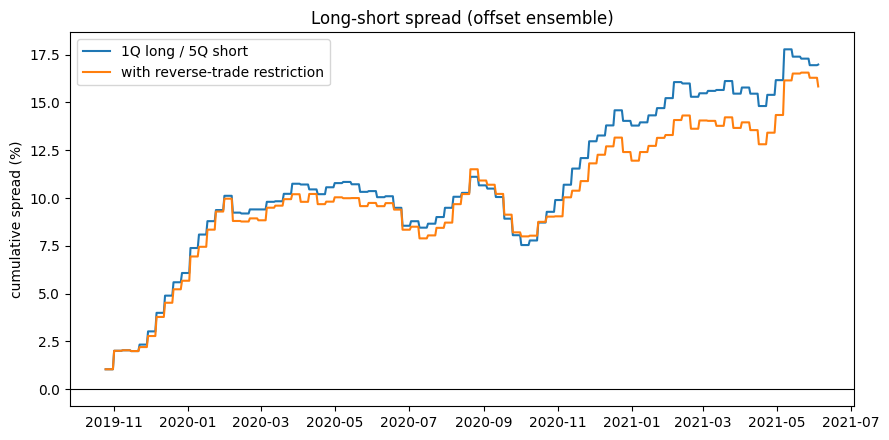

In [11]:
plt.figure(figsize=(9, 4.5))
plt.plot(ens_ls_plain.index, ens_ls_plain.values * 100, label="1Q long / 5Q short")
plt.plot(ens_ls_restricted.index, ens_ls_restricted.values * 100,
         label="with reverse-trade restriction")
plt.axhline(0, color="k", lw=0.8)
plt.ylabel("cumulative spread (%)")
plt.title("Long-short spread (offset ensemble)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "long_short_spread.png", dpi=120)
plt.show()

## Cell 9: turnover와 제한 전/후 비교

In [12]:
summary = pd.DataFrame({
    "mean_ls_per_period(%)": [df_bt["ls_plain"].mean() * 100, df_bt["ls_restricted"].mean() * 100],
    "std_ls(%)": [df_bt["ls_plain"].std() * 100, df_bt["ls_restricted"].std() * 100],
    "mean_turnover": [df_bt["turnover_plain"].mean(), df_bt["turnover_restricted"].mean()],
}, index=["plain", "restricted"])
summary["IR_per_period"] = summary["mean_ls_per_period(%)"] / summary["std_ls(%)"]
summary.round(3)

,mean_ls_per_period(%),std_ls(%),mean_turnover,IR_per_period
plain,0.799,2.192,0.824,0.365
restricted,0.745,2.329,0.825,0.320
